# HapSleep — POC 1.5: laboratorio sintético con verdad conocida

**Para qué sirve un laboratorio sintético (y para qué no).** Aquí los datos los generamos nosotros, así que **sabemos la
verdad**: cada persona simulada tiene un puntaje verdadero de calidad de sueño (escala 0–21, más alto = peor, con corte
fijo en 5). Eso permite responder preguntas que con datos reales no se pueden comprobar. **No mide el desempeño real del
modelo:** los resultados dependen de los supuestos del simulador. Sirve para *comparar diseños* y para *planificar*.

**Tres preguntas:**
1. **Definición de la etiqueta.** Si la población cambia (todos duermen mal, mixta, todos duermen bien), ¿qué se rompe:
   la etiqueta por percentil (POC1), un corte fijo, o predecir un puntaje continuo con corte después (POC 1.3)?
2. **¿Qué esperar con 50 personas?** ¿Cuánto varían los resultados entre "estudios" de 50 personas, y cómo empeoran al
   ensuciar los datos (ruido entre personas, datos faltantes, pocas noches)?
3. **Efecto del tamaño.** ¿Qué cambia con 30, 50 o 100 personas?

## Cómo se generan los datos

1. **Puntaje verdadero de calidad de sueño** de cada persona: entero de 0 a 21, más alto = peor. Se sortea de una
   distribución que depende de la población:

| Población | Media | Desv. estándar | % con puntaje ≥ 5 (aprox.) |
|---|---|---|---|
| Duermen mal | 7.0 | 3.0 | ~77% (medido en las simulaciones) |
| Mixta | 4.5 | 3.0 | ~49% |
| Duermen bien | 3.0 | 2.5 | ~26% |

(Se descartan las cohortes con menos de 6 personas de una de las dos clases, porque no se podrían validar; eso baja
un poco la prevalencia medida en la población que duerme mal.)

2. **Variables del reloj.** Las mismas 11 de POC1. Cada día de cada persona se genera a partir de su puntaje, con las
   mismas ecuaciones que el simulador de `poc2/` (por ejemplo, más puntaje → menos pasos, más minutos despierto y más
   inconsistencia noche a noche). Excepción: `minutesToFallAsleep` se deja **sin señal**, porque en los datos reales casi
   siempre vale 0.
3. **Seis niveles de dificultad**, del laboratorio limpio a uno más difícil que LifeSnaps:

| Nivel | Qué agrega |
|---|---|
| L0 Limpio | Solo ruido día a día (que se promedia). Es el mundo de `poc2/`. |
| L1 Ruido entre personas moderado | Cada persona tiene un nivel base propio (pulso, pasos…) que **no se promedia** y no tiene que ver con el sueño |
| L2 Ruido entre personas alto | Ese nivel base propio pesa el doble |
| L3 Como LifeSnaps | L2 + datos faltantes: SpO2 sin datos en 61% de las personas, HRV/pulso nocturno/respiración en 39%, solo ~48% de las noches con dato, y 13% de personas con menos de 10 noches |
| L4 El reloj ve solo parte del puntaje (r = 0.7) | L3 + el reloj refleja solo una parte del puntaje verdadero: la correlación entre ambos es 0.7 |
| L5 El reloj ve menos aún (r = 0.5) | L3 + correlación de 0.5 |

**Por qué L4 y L5.** Los niveles L0–L3 siguen siendo un mundo "fácil": las 22 variables reflejan el mismo puntaje, así que
el modelo las combina y acierta aunque cada una sea ruidosa. En la realidad el puntaje verdadero (por ejemplo, un
cuestionario como el PSQI) incluye cosas que un reloj **no puede ver**: la calidad subjetiva, el uso de medicación o la
somnolencia diurna. En L4 y L5 se simula eso. **Los valores de r son hipotéticos:** cuánto del puntaje refleja
realmente el reloj es justo lo que aún no se sabe, y lo dirá el estudio real.

4. **Resumen por persona** idéntico al de POC1: media y desviación estándar de cada variable (22 features), con
   faltantes rellenados con la mediana.

**Un "estudio" = una cohorte simulada de n personas.** Se simulan muchas cohortes independientes y se mira cómo varían
los resultados entre ellas, que es justo lo que pasaría si repitieras tu estudio con otros 50 estudiantes.

## Los tres enfoques que se comparan

Todos usan Random Forest y **las mismas particiones** de validación cruzada (5-Fold; se evalúa siempre con personas no
vistas). Lo que cambia es **qué se le pide aprender**:

| Enfoque | Qué aprende | Cómo decide "riesgo alto" |
|---|---|---|
| **Percentil** (POC1) | Estar en el 25% peor **de la muestra** | Probabilidad ≥ 0.5 |
| **Corte fijo** | Tener puntaje ≥ 5 | Probabilidad ≥ 0.5 |
| **Puntaje continuo** (POC 1.3) | El puntaje 0–21 | Puntaje estimado ≥ 5 |

**Contra qué se evalúa:** siempre contra la **verdad absoluta**: ¿la persona realmente tiene puntaje ≥ 5?

**Métricas:** *Recall* (de los que realmente están en riesgo, ¿a cuántos detecta?), *Precisión*, *F1*, *ROC-AUC* (¿ordena
bien a las personas, sin depender de dónde se ponga el corte?) y el **% que el enfoque clasifica como alto** frente al %
que realmente lo está. Se muestra además el F1 de un modelo tonto que siempre dice "riesgo alto": con prevalencia alta
ese F1 ya es alto, así que el F1 solo engaña.

**Nota de protocolo:** en cada cohorte se hace 5-Fold × 3 repeticiones (150 árboles) y no × 20, porque se corren muchas
cohortes; la variación entre cohortes es la incertidumbre relevante y cubre a la de las repeticiones.

In [1]:
import sys
import warnings

try:
    sys.stdout.reconfigure(encoding="utf-8")  # consola de Windows por defecto usa cp1252, truena con tildes
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Simulador y evaluación

In [2]:
CUTOFF = 5              # corte fijo tipo PSQI: >= 5 = mala calidad (el de tu proyecto)
N_TREES = 150
RANDOM_STATE = 42

# (media, desviación) del puntaje verdadero tipo PSQI (0-21) en cada población
POPULATIONS = {
    "Duermen mal": (7.0, 3.0),
    "Mixta": (4.5, 3.0),
    "Duermen bien": (3.0, 2.5),
}

# k = ruido ENTRE personas (nivel base propio de cada persona, no se promedia con los días)
LEVELS = {
    "L0 Limpio": dict(k=0.0, missing=False, r=1.0),
    "L1 Ruido entre personas moderado": dict(k=0.5, missing=False, r=1.0),
    "L2 Ruido entre personas alto": dict(k=1.0, missing=False, r=1.0),
    "L3 Como LifeSnaps (ruido alto + faltantes)": dict(k=1.0, missing=True, r=1.0),
    "L4 L3 + el reloj solo ve parte del puntaje (r=0.7)": dict(k=1.0, missing=True, r=0.7),
    "L5 L3 + el reloj solo ve parte del puntaje (r=0.5)": dict(k=1.0, missing=True, r=0.5),
}
# r = correlación entre el puntaje verdadero y la parte del puntaje que el reloj puede reflejar
# (el resto, p. ej. calidad subjetiva o somnolencia diurna, el reloj no lo ve). r=1: lo ve todo.

# variable: (base, pendiente respecto al riesgo latente 0-1, desviación diaria)
VARS = {
    "rmssd": (45.0, -15.0, 8.0),
    "nremhr": (62.0, 8.0, 5.0),
    "resting_hr": (65.0, 6.0, 6.0),
    "spo2": (96.5, -1.5, 0.8),
    "full_sleep_breathing_rate": (15.0, 1.0, 1.2),
    "minutesToFallAsleep": (0.0, 0.0, 2.0),   # sin señal: en LifeSnaps casi siempre vale 0
    "minutesAsleep": (430.0, -80.0, 40.0),
    "minutesAwake": (20.0, 35.0, None),       # desviación diaria = 8 + 20 * riesgo
    "sleep_efficiency": (0.90, -0.20, 0.05),
    "steps": (8500.0, -3000.0, 1800.0),
    "sedentary_minutes": (450.0, 200.0, None),  # desviación diaria = 40 + 60 * riesgo
}
SLEEP_VARS = ["minutesToFallAsleep", "minutesAsleep", "minutesAwake", "sleep_efficiency"]
TRIO_VARS = ["rmssd", "nremhr", "full_sleep_breathing_rate"]


def _daily(v, L, offset, n_days, rng):
    base, slope, sd = VARS[v]
    if v == "minutesAwake":
        sd = 8 + 20 * L
    if v == "sedentary_minutes":
        sd = 40 + 60 * L
    x = base + slope * L + offset + rng.normal(0, sd, n_days)
    if v == "rmssd":
        x = np.maximum(5, x)
    elif v == "minutesAsleep":
        x = np.maximum(120, x)
    elif v in ("minutesAwake", "steps", "sedentary_minutes", "minutesToFallAsleep"):
        x = np.maximum(0, x)
    elif v == "spo2":
        x = np.clip(x, 88, 100)
    elif v == "sleep_efficiency":
        x = np.clip(x, 0.4, 1.0)
    return x


def _mean_std(x):
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return x.mean(), (x.std(ddof=1) if len(x) > 1 else np.nan)


def simulate_cohort(n, pop, level, rng):
    mean, sd = POPULATIONS[pop]
    S = np.clip(np.round(rng.normal(mean, sd, n)), 0, 21)
    cfg = LEVELS[level]
    k, miss, r_vis = cfg["k"], cfg["missing"], cfg["r"]
    # parte del puntaje que el reloj puede reflejar: correlación r_vis con el puntaje verdadero
    mean_p, sd_p = mean, sd
    W = mean_p + r_vis * (S - mean_p) + np.sqrt(1 - r_vis ** 2) * sd_p * rng.normal(0, 1, n)
    L_all = np.clip(W / 15, 0, 1)
    feats = []
    for i in range(n):
        L = L_all[i]
        n_days = int(rng.integers(64, 150)) if miss else int(rng.integers(30, 120))
        offs = {v: (rng.normal(0, k * 0.5 * abs(VARS[v][1])) if VARS[v][1] != 0 else 0.0) for v in VARS}
        data = {v: _daily(v, L, offs[v], n_days, rng) for v in VARS}
        if miss:
            keep = lambda p: rng.random(n_days) < p
            few = rng.random() < 0.13
            if few:
                sleep_mask = np.zeros(n_days, bool)
                sleep_mask[rng.choice(n_days, size=int(rng.integers(3, 10)), replace=False)] = True
            else:
                sleep_mask = keep(0.48)
            trio_mask = keep(0.48) if rng.random() >= 0.39 else np.zeros(n_days, bool)
            spo2_mask = keep(0.48) if rng.random() >= 0.61 else np.zeros(n_days, bool)
            masks = {v: sleep_mask for v in SLEEP_VARS}
            masks.update({v: trio_mask for v in TRIO_VARS})
            masks.update({"spo2": spo2_mask, "resting_hr": keep(0.60), "steps": keep(0.64), "sedentary_minutes": keep(0.96)})
            for v in VARS:
                data[v] = np.where(masks[v], data[v], np.nan)
        row = {}
        for v in VARS:
            m, s = _mean_std(data[v])
            row[f"{v}_mean"] = m
            row[f"{v}_std"] = s
        feats.append(row)
    X = pd.DataFrame(feats).rename(columns={"minutesAsleep_std": "sleep_duration_inconsistency"})
    X = X.fillna(X.median())
    return X, S


def _rf_clf():
    return RandomForestClassifier(n_estimators=N_TREES, max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)


def _rf_reg():
    return RandomForestRegressor(n_estimators=N_TREES, max_depth=5, random_state=RANDOM_STATE)


def _metrics(y_abs, score, decision):
    return {
        "precision": precision_score(y_abs, decision, zero_division=0),
        "recall": recall_score(y_abs, decision, zero_division=0),
        "f1": f1_score(y_abs, decision, zero_division=0),
        "roc_auc": roc_auc_score(y_abs, score),
        "pct_predicho_alto": float(np.mean(decision)),
    }


def evaluate_cohort(X, S, approaches=("Percentil", "Corte fijo", "Puntaje continuo"), n_repeats=3, seed=0):
    y_abs = (S >= CUTOFF).astype(int)
    y_pct = (S >= np.quantile(S, 0.75)).astype(int)
    acc = {a: [] for a in approaches}
    spear = []
    for r in range(n_repeats):
        folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=seed + r).split(X, y_abs))
        for a in approaches:
            if a == "Percentil":
                proba = cross_val_predict(_rf_clf(), X, y_pct, cv=folds, method="predict_proba")[:, 1]
                acc[a].append(_metrics(y_abs, proba, (proba >= 0.5).astype(int)))
            elif a == "Corte fijo":
                proba = cross_val_predict(_rf_clf(), X, y_abs, cv=folds, method="predict_proba")[:, 1]
                acc[a].append(_metrics(y_abs, proba, (proba >= 0.5).astype(int)))
            else:
                pred = cross_val_predict(_rf_reg(), X, S, cv=folds)
                acc[a].append(_metrics(y_abs, pred, (pred >= CUTOFF).astype(int)))
                spear.append(spearmanr(S, pred).correlation)
    out = []
    for a in approaches:
        d = pd.DataFrame(acc[a]).mean().to_dict()
        d["Enfoque"] = a
        d["prevalencia_real"] = float(y_abs.mean())
        d["positivos"] = int(y_abs.sum())
        d["f1_siempre_alto"] = 2 * y_abs.mean() / (1 + y_abs.mean())
        d["spearman"] = float(np.mean(spear)) if (a == "Puntaje continuo" and spear) else np.nan
        out.append(d)
    return out


def _one_cohort(c, pop, level, n, approaches, n_repeats, base_seed):
    for t in range(200):
        rng = np.random.default_rng(base_seed + c * 1000 + t)
        X, S = simulate_cohort(n, pop, level, rng)
        y_abs = (S >= CUTOFF)
        if y_abs.sum() >= 6 and (~y_abs).sum() >= 6:   # hace falta un mínimo de cada clase para validar
            rows = evaluate_cohort(X, S, approaches, n_repeats, seed=RANDOM_STATE)
            for d in rows:
                d.update({"Población": pop, "Nivel": level, "n": n, "cohorte": c})
            return rows
    raise RuntimeError("no se pudo generar una cohorte válida")


def run_experiment(pop, level, n, n_cohorts, approaches=("Percentil", "Corte fijo", "Puntaje continuo"),
                   n_repeats=3, base_seed=1000):
    # cada cohorte es un "estudio" independiente de n personas; se corren en paralelo
    results = Parallel(n_jobs=-1)(
        delayed(_one_cohort)(c, pop, level, n, approaches, n_repeats, base_seed) for c in range(n_cohorts)
    )
    return pd.DataFrame([row for rows in results for row in rows])


### Una cohorte de ejemplo por población (verificación rápida)

In [3]:
rows = []
for pop in POPULATIONS:
    X_ex, S_ex = simulate_cohort(50, pop, "L1 Ruido entre personas moderado", np.random.default_rng(7))
    rows.append({"Población": pop, "Puntaje medio": round(S_ex.mean(), 2),
                 "% con puntaje ≥ 5": f"{(S_ex >= CUTOFF).mean():.0%}", "Features": X_ex.shape[1]})
pd.DataFrame(rows)


,Población,Puntaje medio,% con puntaje ≥ 5,Features
0,Duermen mal,6.06,74%,22
1,Mixta,3.84,40%,22
2,Duermen bien,2.46,14%,22


# Parte 1 — ¿Qué se rompe cuando cambia la población?

n = 50 personas por estudio y 30 estudios simulados por población, en dos niveles: **L1** (datos informativos, para que
cualquier falla se deba a la definición de la etiqueta y no a la falta de señal) y **L4** (el reloj ve solo parte del
puntaje, un caso más cercano a la realidad).

In [4]:
N_STUDY = 50
N_COHORTS = 30
L1 = "L1 Ruido entre personas moderado"
L4 = "L4 L3 + el reloj solo ve parte del puntaje (r=0.7)"

p1_all = pd.concat(
    [run_experiment(pop, lvl, N_STUDY, N_COHORTS) for lvl in (L1, L4) for pop in POPULATIONS], ignore_index=True
)


def ms(s, d=2):
    return f"{s.mean():.{d}f} ± {s.std(ddof=0):.{d}f}"


def table_p1(p1):
    rows = []
    for pop in POPULATIONS:
        for ap in ["Percentil", "Corte fijo", "Puntaje continuo"]:
            d = p1[(p1["Población"] == pop) & (p1["Enfoque"] == ap)]
            rows.append({
                "Población": pop, "Enfoque": ap,
                "% real en riesgo alto": f"{d['prevalencia_real'].mean():.0%}",
                "% que el enfoque marca alto": f"{d['pct_predicho_alto'].mean():.0%}",
                "Recall": ms(d["recall"]), "Precisión": ms(d["precision"]), "F1": ms(d["f1"]),
                "F1 de 'siempre alto'": f"{d['f1_siempre_alto'].mean():.2f}",
                "ROC-AUC": ms(d["roc_auc"]),
            })
    return pd.DataFrame(rows)


print("=== Nivel L1: datos informativos ===")
display(table_p1(p1_all[p1_all["Nivel"] == L1]))
print("=== Nivel L4: el reloj ve solo parte del puntaje (r = 0.7) ===")
display(table_p1(p1_all[p1_all["Nivel"] == L4]))


=== Nivel L1: datos informativos ===


,Población,Enfoque,% real en riesgo alto,% que el enfoque marca alto,Recall,Precisión,F1,F1 de 'siempre alto',ROC-AUC
0,Duermen mal,Percentil,77%,32%,0.42 ± 0.06,1.00 ± 0.00,0.59 ± 0.06,0.87,0.93 ± 0.04
1,Duermen mal,Corte fijo,77%,78%,0.96 ± 0.03,0.96 ± 0.02,0.96 ± 0.02,0.87,0.97 ± 0.03
2,Duermen mal,Puntaje continuo,77%,74%,0.93 ± 0.04,0.97 ± 0.02,0.95 ± 0.02,0.87,0.98 ± 0.02
3,Mixta,Percentil,49%,32%,0.65 ± 0.11,0.99 ± 0.02,0.78 ± 0.08,0.66,0.96 ± 0.02
4,Mixta,Corte fijo,49%,50%,0.92 ± 0.04,0.91 ± 0.04,0.91 ± 0.04,0.66,0.97 ± 0.01
5,Mixta,Puntaje continuo,49%,44%,0.85 ± 0.08,0.95 ± 0.03,0.90 ± 0.05,0.66,0.97 ± 0.02
6,Duermen bien,Percentil,26%,34%,0.92 ± 0.09,0.70 ± 0.14,0.78 ± 0.08,0.41,0.96 ± 0.02
7,Duermen bien,Corte fijo,26%,27%,0.84 ± 0.10,0.81 ± 0.09,0.82 ± 0.09,0.41,0.96 ± 0.03
8,Duermen bien,Puntaje continuo,26%,20%,0.67 ± 0.21,0.89 ± 0.09,0.74 ± 0.17,0.41,0.96 ± 0.03


=== Nivel L4: el reloj ve solo parte del puntaje (r = 0.7) ===


,Población,Enfoque,% real en riesgo alto,% que el enfoque marca alto,Recall,Precisión,F1,F1 de 'siempre alto',ROC-AUC
0,Duermen mal,Percentil,77%,30%,0.37 ± 0.07,0.95 ± 0.04,0.52 ± 0.08,0.87,0.75 ± 0.07
1,Duermen mal,Corte fijo,77%,78%,0.85 ± 0.05,0.85 ± 0.04,0.85 ± 0.04,0.87,0.75 ± 0.09
2,Duermen mal,Puntaje continuo,77%,83%,0.90 ± 0.05,0.83 ± 0.04,0.86 ± 0.04,0.87,0.76 ± 0.08
3,Mixta,Percentil,49%,30%,0.45 ± 0.08,0.75 ± 0.12,0.55 ± 0.08,0.66,0.74 ± 0.07
4,Mixta,Corte fijo,49%,49%,0.68 ± 0.09,0.69 ± 0.10,0.69 ± 0.09,0.66,0.74 ± 0.09
5,Mixta,Puntaje continuo,49%,40%,0.59 ± 0.13,0.74 ± 0.09,0.65 ± 0.11,0.66,0.75 ± 0.07
6,Duermen bien,Percentil,26%,32%,0.62 ± 0.14,0.50 ± 0.13,0.54 ± 0.11,0.41,0.76 ± 0.08
7,Duermen bien,Corte fijo,26%,24%,0.50 ± 0.15,0.54 ± 0.14,0.51 ± 0.14,0.41,0.76 ± 0.09
8,Duermen bien,Puntaje continuo,26%,7%,0.17 ± 0.15,0.50 ± 0.28,0.23 ± 0.19,0.41,0.78 ± 0.06


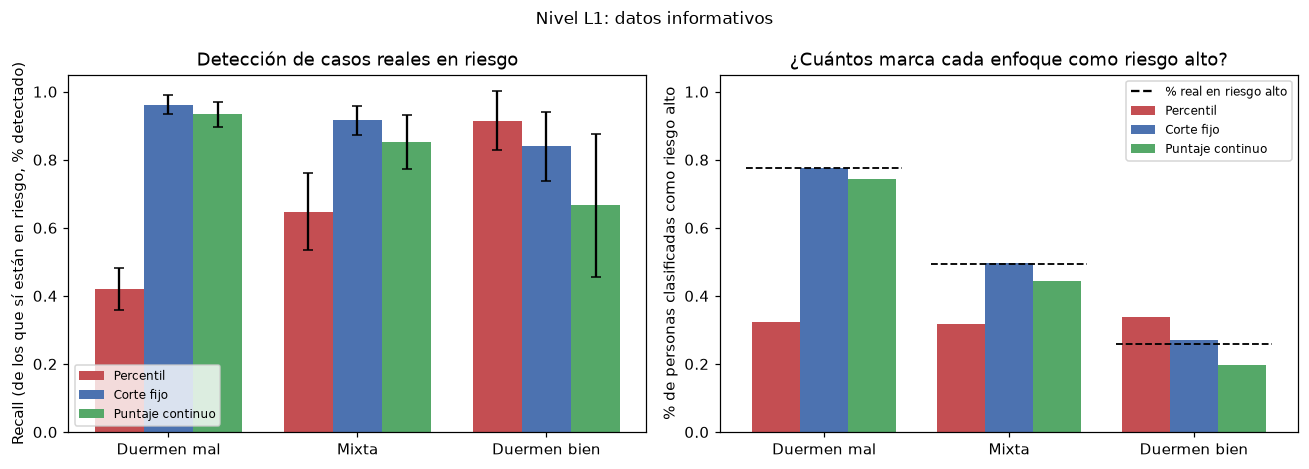

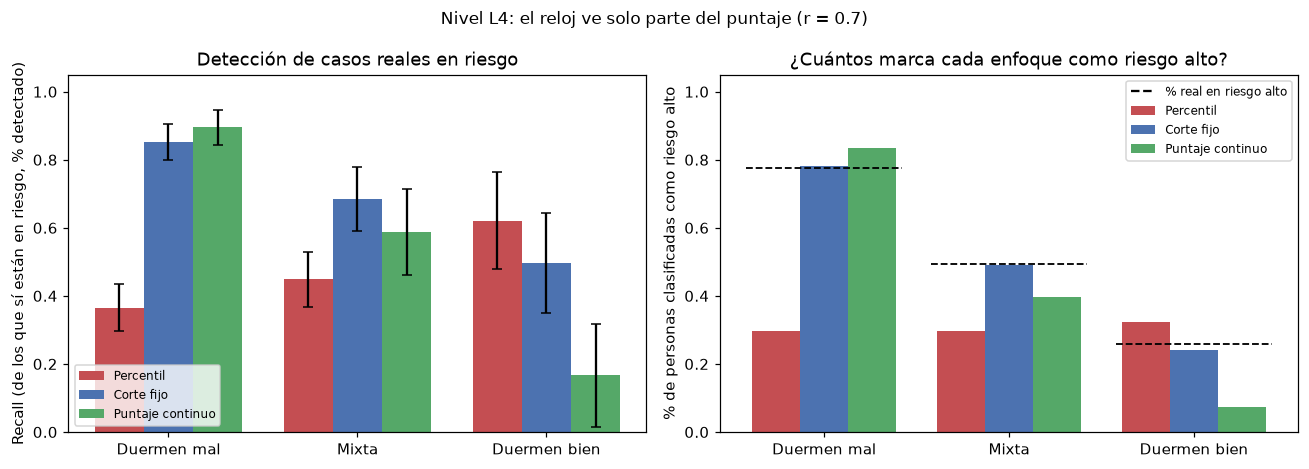

In [5]:
colors = {"Percentil": "#C44E52", "Corte fijo": "#4C72B0", "Puntaje continuo": "#55A868"}
approaches = ["Percentil", "Corte fijo", "Puntaje continuo"]
pops = list(POPULATIONS)
x = np.arange(len(pops))
w = 0.26


def plot_p1(p1, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
    fig.suptitle(title, fontsize=11)
    for i, ap in enumerate(approaches):
        m = [p1[(p1["Población"] == p) & (p1["Enfoque"] == ap)]["recall"].mean() for p in pops]
        s = [p1[(p1["Población"] == p) & (p1["Enfoque"] == ap)]["recall"].std(ddof=0) for p in pops]
        axes[0].bar(x + (i - 1) * w, m, w, yerr=s, capsize=3, label=ap, color=colors[ap])
    axes[0].set_xticks(x); axes[0].set_xticklabels(pops)
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Recall (de los que sí están en riesgo, % detectado)")
    axes[0].set_title("Detección de casos reales en riesgo")
    axes[0].legend(fontsize=8, loc="lower left")

    for i, ap in enumerate(approaches):
        m = [p1[(p1["Población"] == p) & (p1["Enfoque"] == ap)]["pct_predicho_alto"].mean() for p in pops]
        axes[1].bar(x + (i - 1) * w, m, w, label=ap, color=colors[ap])
    real = [p1[(p1["Población"] == p) & (p1["Enfoque"] == "Corte fijo")]["prevalencia_real"].mean() for p in pops]
    for xi, r in zip(x, real):
        axes[1].plot([xi - 0.42, xi + 0.42], [r, r], color="k", ls="--", lw=1.2)
    axes[1].plot([], [], color="k", ls="--", label="% real en riesgo alto")
    axes[1].set_xticks(x); axes[1].set_xticklabels(pops)
    axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("% de personas clasificadas como riesgo alto")
    axes[1].set_title("¿Cuántos marca cada enfoque como riesgo alto?")
    axes[1].legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()


plot_p1(p1_all[p1_all["Nivel"] == L1], "Nivel L1: datos informativos")
plot_p1(p1_all[p1_all["Nivel"] == L4], "Nivel L4: el reloj ve solo parte del puntaje (r = 0.7)")


## Lectura de la Parte 1

**Lo que se rompe con el percentil.**
- Marca alrededor del **30%** como riesgo alto **en cualquier población** (32%, 32% y 34% en L1; 30%, 30% y 32% en L4),
  aunque en realidad sea 77%, 49% o 26%. Donde casi todos duermen mal detecta solo el 42% de los casos reales (37% en L4),
  y su F1 (0.59) queda por debajo del de un modelo tonto que siempre dice "alto" (0.87).
- Su **ROC-AUC sigue alto** (0.93 en L1; 0.75 en L4): ordena bien a las personas. Lo que falla es la decisión
  "riesgo alto sí o no", porque el corte depende del grupo.

**Lo que aguanta.**
- **Corte fijo:** marca casi lo que hay en realidad en las tres poblaciones (78%, 50%, 27% frente a 77%, 49%, 26% en L1; y
  78%, 49%, 24% en L4, con más errores).
- **Puntaje continuo con corte:** funciona bien en L1 (F1 0.95, 0.90, 0.74), pero **con señal débil (L4) se contrae hacia el
  promedio**: sobre-marca donde casi todos duermen mal (83% frente a 77% real) y casi no detecta donde duermen bien (marca 7%
  frente a 26% real; recall 0.17). Cuando el reloj refleja poco del puntaje, aplicar el corte a un puntaje estimado es menos
  robusto de lo que parecía en POC 1.3.

**Advertencia sobre el F1.** En L4 el F1 del corte fijo (0.85, 0.69, 0.51) es casi igual al de un modelo tonto que siempre
dice "alto" (0.87, 0.66, 0.41). El F1 solo no dice si el modelo aporta algo. El **ROC-AUC (≈ 0.75 en L4 para los tres
enfoques)** es la medida informativa aquí: hay señal, pero las decisiones cerca del corte son poco confiables.

**Consecuencia de diseño.** No usar percentil: el nivel de riesgo debe salir de un **corte absoluto**. En esta simulación el
clasificador entrenado con el corte fijo es el más estable para decir "riesgo alto sí o no", y el puntaje continuo aporta
la gradación y el rango. Podrían combinarse: nivel de riesgo desde el clasificador con corte fijo, y puntaje estimado con
su rango para la app y el LLM.


# Parte 2 — ¿Qué esperar con 50 personas? (según cuán sucios sean los datos)

Se usa el enfoque **puntaje continuo** (el diseño propuesto), población **mixta** y n = 50. 30 estudios simulados por
nivel. Se muestra el promedio y el rango **entre estudios** (percentiles 5 a 95): es decir, qué tan distinto podría salir
tu estudio real solo según qué 50 personas te toquen.

In [6]:
p2 = pd.concat(
    [run_experiment("Mixta", lvl, 50, N_COHORTS, approaches=("Puntaje continuo",)) for lvl in LEVELS],
    ignore_index=True,
)


def rng90(s, d=2):
    return f"{s.mean():.{d}f}  [{s.quantile(0.05):.{d}f} – {s.quantile(0.95):.{d}f}]"


rows = []
for lvl in LEVELS:
    d = p2[p2["Nivel"] == lvl]
    rows.append({"Nivel": lvl, "Spearman (puntaje vs. verdad)": rng90(d["spearman"]),
                 "ROC-AUC (vs. corte fijo)": rng90(d["roc_auc"]), "F1": rng90(d["f1"])})
pd.DataFrame(rows)


,Nivel,Spearman (puntaje vs. verdad),ROC-AUC (vs. corte fijo),F1
0,L0 Limpio,0.99 [0.98 – 0.99],1.00 [1.00 – 1.00],0.94 [0.89 – 0.98]
1,L1 Ruido entre personas moderado,0.93 [0.90 – 0.97],0.97 [0.94 – 0.99],0.90 [0.81 – 0.96]
2,L2 Ruido entre personas alto,0.90 [0.86 – 0.95],0.96 [0.92 – 0.99],0.87 [0.77 – 0.94]
3,L3 Como LifeSnaps (ruido alto + faltantes),0.91 [0.87 – 0.94],0.96 [0.93 – 0.99],0.87 [0.77 – 0.95]
4,L4 L3 + el reloj solo ve parte del puntaje (r=...,0.49 [0.33 – 0.61],0.75 [0.63 – 0.83],0.65 [0.44 – 0.79]
5,L5 L3 + el reloj solo ve parte del puntaje (r=...,0.25 [0.03 – 0.41],0.63 [0.50 – 0.73],0.51 [0.29 – 0.71]


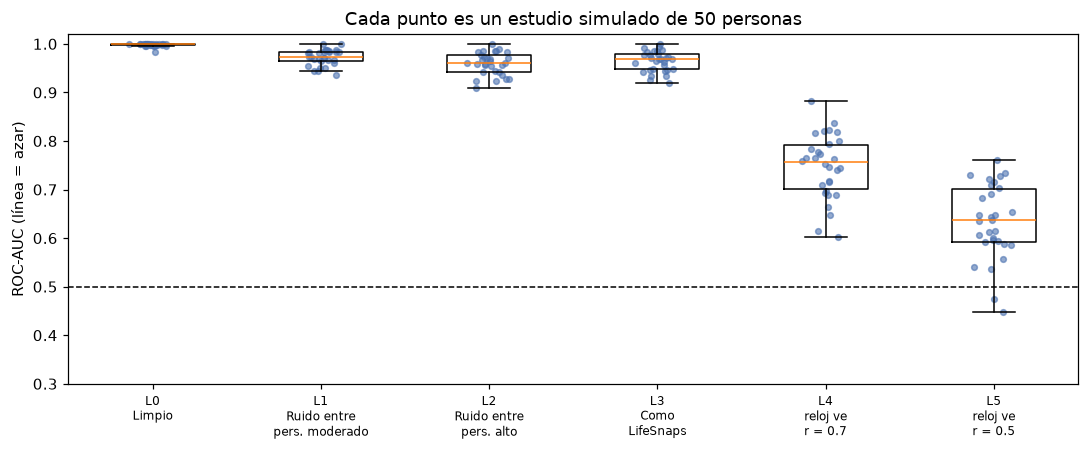

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.2))
data = [p2[p2["Nivel"] == lvl]["roc_auc"].values for lvl in LEVELS]
ax.boxplot(data, showfliers=False, widths=0.5)
rng_j = np.random.default_rng(0)
for i, d in enumerate(data, start=1):
    ax.scatter(i + rng_j.normal(0, 0.06, len(d)), d, s=14, color="#4C72B0", alpha=0.6)
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_xticklabels(["L0\nLimpio", "L1\nRuido entre\npers. moderado", "L2\nRuido entre\npers. alto",
                    "L3\nComo\nLifeSnaps", "L4\nreloj ve\nr = 0.7", "L5\nreloj ve\nr = 0.5"], fontsize=8)
ax.set_ylim(0.3, 1.02)
ax.set_ylabel("ROC-AUC (línea = azar)")
ax.set_title("Cada punto es un estudio simulado de 50 personas")
plt.tight_layout()
plt.show()


### ¿Cuántos casos positivos (puntaje ≥ 5) habrá entre 50 personas?

In [8]:
d = p1_all[(p1_all["Enfoque"] == "Corte fijo") & (p1_all["Nivel"] == L1)]
rows = []
for pop in POPULATIONS:
    s = d[d["Población"] == pop]["positivos"]
    rows.append({"Población": pop, "% real en riesgo alto": f"{d[d['Población'] == pop]['prevalencia_real'].mean():.0%}",
                 "Positivos entre 50 (mediana)": int(s.median()),
                 "Rango 5–95%": f"{int(s.quantile(0.05))} – {int(s.quantile(0.95))}"})
pd.DataFrame(rows)


,Población,% real en riesgo alto,Positivos entre 50 (mediana),Rango 5–95%
0,Duermen mal,77%,38,33 – 43
1,Mixta,49%,24,18 – 31
2,Duermen bien,26%,12,9 – 18


## Lectura de la Parte 2

- **Lo que más pesa no es cuán sucios estén los datos, sino cuánto del puntaje puede reflejar el reloj.** De L1 a L3 (ruido
  entre personas y datos faltantes) el ROC-AUC casi no cambia (0.97 → 0.96). Cae a **0.75 con r = 0.7** y a **0.63 con
  r = 0.5**, donde algunos estudios llegan a valores de azar (percentil 5 = 0.50). *Ojo:* L0–L3 son un mundo "fácil" (todas
  las variables reflejan el mismo puntaje), por eso los faltantes casi no lo afectan.
- **El valor real de r es desconocido** y solo lo dirá el estudio con datos reales. Si el resultado real cae entre 0.6 y
  0.8 de ROC-AUC, no implica que el pipeline esté mal: puede ser justo lo que refleja el reloj.
- **Cuánto varía un estudio de 50 personas solo por azar** (con r = 0.7): el ROC-AUC va de 0.63 a 0.83 y el F1 de 0.44 a
  0.79, según qué 50 personas te toquen. Un resultado de tu estudio real hay que leerlo con ese rango.
- **Casos positivos entre 50 personas.** Si la población duerme mal, esperarías unos 38 positivos (33 a 43) y solo ~12
  negativos; si duerme bien, ~12 positivos (9 a 18). En poblaciones extremas la clase minoritaria queda con menos de 18
  personas, lo que limita la validación. Conviene estimar la proporción real con un piloto antes del estudio completo.


# Parte 3 — Efecto del tamaño del estudio

Enfoque continuo, población mixta, nivel **L4** (el reloj ve solo parte del puntaje), con n = 30, 50 y 100 personas.

,Personas por estudio,Spearman,ROC-AUC,F1,Positivos (mediana)
0,30,0.38 [-0.01 – 0.63],0.70 [0.48 – 0.88],0.57 [0.20 – 0.84],15
1,50,0.49 [0.33 – 0.61],0.75 [0.63 – 0.83],0.65 [0.44 – 0.79],24
2,100,0.52 [0.43 – 0.59],0.76 [0.72 – 0.82],0.66 [0.57 – 0.76],51


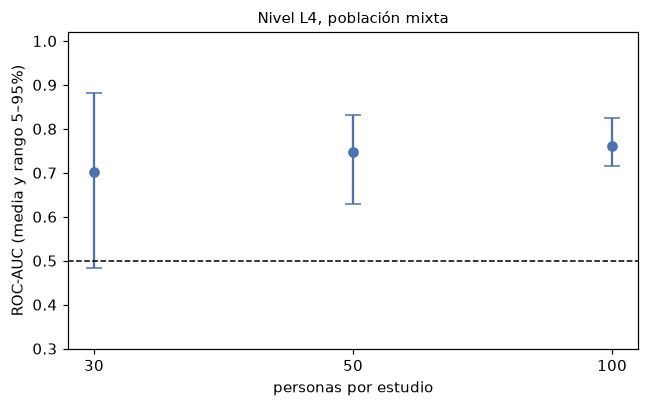

In [9]:
p3 = pd.concat(
    [run_experiment("Mixta", L4, n, N_COHORTS, approaches=("Puntaje continuo",)) for n in [30, 50, 100]],
    ignore_index=True,
)

rows = []
for n in [30, 50, 100]:
    d = p3[p3["n"] == n]
    rows.append({"Personas por estudio": n, "Spearman": rng90(d["spearman"]),
                 "ROC-AUC": rng90(d["roc_auc"]), "F1": rng90(d["f1"]),
                 "Positivos (mediana)": int(d["positivos"].median())})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(6, 3.8))
for i, n in enumerate([30, 50, 100]):
    s = p3[p3["n"] == n]["roc_auc"]
    ax.errorbar(i, s.mean(), yerr=[[s.mean() - s.quantile(0.05)], [s.quantile(0.95) - s.mean()]],
                fmt="o", capsize=5, color="#4C72B0")
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_xticks(range(3)); ax.set_xticklabels(["30", "50", "100"])
ax.set_xlabel("personas por estudio"); ax.set_ylabel("ROC-AUC (media y rango 5–95%)")
ax.set_ylim(0.3, 1.02)
ax.set_title("Nivel L4, población mixta", fontsize=10)
plt.tight_layout()
plt.show()


## Lectura de la Parte 3

Con más personas el **promedio casi no cambia** (ROC-AUC 0.70, 0.75 y 0.76 con 30, 50 y 100), pero el **rango se estrecha
mucho**: 0.48–0.88 con 30 personas, 0.63–0.83 con 50 y 0.72–0.82 con 100. Con 30 personas, un mal reparto puede dar un
resultado que parece azar (percentil 5 = 0.48). Más gente no mejora el modelo tanto como reduce la incertidumbre de la
conclusión: con 50 personas el resultado es utilizable pero todavía ancho.


## Qué se lleva de este laboratorio

1. **La etiqueta debe ser absoluta, no un percentil del grupo.** El percentil marca ~30% como riesgo alto sin importar la
   población; con un corte fijo el nivel de riesgo sigue a la realidad.
2. **Las métricas.** Con prevalencia alta o señal débil, el F1 se confunde con el de un modelo tonto. Hay que mirar el
   ROC-AUC y compararlo siempre con el baseline.
3. **Qué esperar.** El resultado depende sobre todo de cuánto del puntaje refleja el reloj (desconocido) y, con 50 personas,
   varía unos ±0.1 en ROC-AUC solo por qué personas te toquen. Conviene definir el criterio de éxito de la tesis con esa
   incertidumbre en mente.
4. **Nada de esto es desempeño real.** Es un laboratorio con supuestos nuestros; sirve para elegir diseños y planificar, no
   para prometer números.


## Límites de este laboratorio

- **No es desempeño real.** Todo depende de lo que supusimos: relaciones lineales entre el puntaje y las variables, todas
  las variables movidas por el mismo puntaje, ruido gaussiano y faltantes al azar. La vida real puede ser más difícil (o
  distinta) en formas que aquí no están.
- **Los niveles de suciedad los elegimos nosotros.** L3 imita los porcentajes de faltantes de LifeSnaps, pero el "ruido
  entre personas" es un supuesto, no una medición.
- **Relleno con la mediana** antes de validar, igual que POC1 (su fuga leve no se corrige aquí).
- **Protocolo:** 5-Fold × 3 repeticiones por cohorte, con muchas cohortes, en lugar de 5-Fold × 20 sobre un solo conjunto.
- El corte 5 es el de tu proyecto; las conclusiones sobre *qué se rompe* no dependen de su valor exacto.
